### Bone Fracture Classification with `LeNet` and `MLP`

This notebook focuses on training **lightweight deep learning models**—`LeNet` and a **Multilayer Perceptron (MLP)**-for **bone fracture classification** using X-ray images. The objective is to evaluate efficient architectures that provide reliable performance while requiring **minimal computational resources**, making them suitable for deployment in environments with limited hardware capabilities.

The models are trained and evaluated using a publicly available dataset from Kaggle:

> **Bone Fracture X-ray Dataset**  
> https://www.kaggle.com/datasets/usman44m/bone-fracture-x-ray-dataset

The dataset consists of X-ray images categorized into two classes:
- **Fracture**
- **Non-Fracture (Normal)**

The workflow covered in this notebook includes:
- Data loading and preprocessing  
- Model architecture design (`LeNet` and `MLP`)  
- Training and validation  
- Performance evaluation and comparison  

To maintain consistency in experimental design, the same network architectures used in previous notebooks are applied in this study. This enables fair comparison of model performance across different medical imaging tasks.

This project highlights the effectiveness of lightweight models for **binary medical image classification**, particularly in bone fracture detection scenarios.

In the following code cell we are going to import all the packages that we are going to use for the rest of this notebook.

In [111]:
import torch
import random
import os
import time
import torchvision
import copy
import json
from pigmenta import PALETTES
from uuid import uuid4
import shutil
import math

import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import FileLink
from shutil import copyfile
from torch.nn import functional as F
from PIL import Image
from torchvision import datasets, transforms
from torch.utils import data
from PIL import Image
from sklearn.metrics import classification_report
from helperfns.tables import tabulate_data
from helperfns.visualization import plot_complicated_confusion_matrix, plot_simple_confusion_matrix
from helperfns.utils import hms_string
from PIL import ImageFile

from helperfns import visualization
from torchvision import models
import matplotlib as mpl
import warnings
from ptflops import get_model_complexity_info


ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore")

print("torch: ", torch.__version__)
print("numpy: ", np.__version__)
print("pandas: ", pd.__version__)

torch:  2.9.0+cu126
numpy:  2.3.3
pandas:  2.3.3


### Seed

In the following code cell we are going to define the `SEED` for all random operation for reproducivity of results in this notebook.

In [2]:
SEED = 13

random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

### Device

In the following code cell we are going to create a variable `device` that will hold the value of the device that is available so that we can have access to the `GPU` if available.

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Dataset

The dataset used in this project is sourced from Kaggle and consists of labeled X-ray images for **binary bone fracture classification**:

> **Bone Fracture X-ray Dataset**  
> https://www.kaggle.com/datasets/usman44m/bone-fracture-x-ray-dataset

This dataset contains X-ray images categorized into two classes:
- **Fracture**
- **Non-Fracture (Normal)**

The images are already organized into **training, validation, and test sets**, enabling straightforward integration into deep learning pipelines without additional preprocessing for data splitting.

The dataset is well-suited for:
- Convolutional Neural Networks (CNNs)
- Transfer Learning using architectures such as DenseNet, ResNet, and EfficientNet
- Medical image classification tasks
- Healthcare AI research and academic projects

In this project, the same network architectures developed in previous notebooks will be applied to this dataset to ensure consistency in experimental design and allow for comparative performance analysis.

To ensure reproducibility and efficient data access, the dataset will be downloaded programmatically using the **Kaggle API**, enabling seamless integration into the workflow and simplifying data management within the notebook environment.

In [4]:
with open("C:\\Users\\crisp\\Downloads\\kaggle.json", 'r') as reader:
  keys = json.loads(reader.read())
  os.environ['KAGGLE_USERNAME'] = keys['username']
  os.environ['KAGGLE_KEY'] = keys['key']

!kaggle datasets download usman44m/bone-fracture-x-ray-dataset --unzip -q

Dataset URL: https://www.kaggle.com/datasets/usman44m/bone-fracture-x-ray-dataset
License(s): CC-BY-SA-4.0


In the next code cell, we will **count the number of samples in each class** for both the **training** and **testing** datasets. This step helps us understand the **class distribution** and identify any potential imbalance that might affect model training.


In [5]:
train_samples = dict(
    zip(os.listdir('Bone_Fracture_Dataset/train'), [len(os.listdir(os.path.join('Bone_Fracture_Dataset/train', i)))
                                                    for i in os.listdir('Bone_Fracture_Dataset/train')])
)
test_samples =  dict(
    zip(os.listdir('Bone_Fracture_Dataset/test'), [len(os.listdir(os.path.join('Bone_Fracture_Dataset/test', i))) 
                                                   for i in os.listdir('Bone_Fracture_Dataset/test')])
)
val_samples =  dict(
    zip(os.listdir('Bone_Fracture_Dataset/val'), [len(os.listdir(os.path.join('Bone_Fracture_Dataset/val', i))) 
                                                   for i in os.listdir('Bone_Fracture_Dataset/val')])
)

test_samples, train_samples, val_samples

({'fractured': 239, 'not fractured': 269},
 {'fractured': 4607, 'not fractured': 4641},
 {'fractured': 338, 'not fractured': 493})

In the following code cell, we will **visualize the class distribution** of the dataset using a **pie chart**. This graphical representation provides a clear view of the proportion of samples in each class, helping to identify any imbalance in the dataset.


<Figure size 300x300 with 0 Axes>

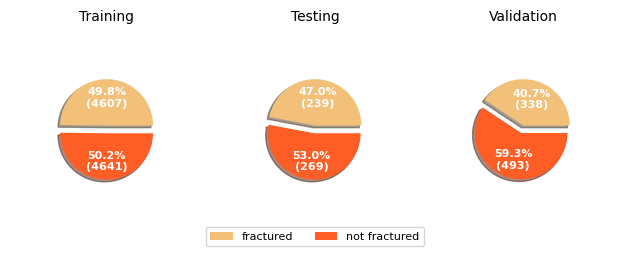

In [6]:
plt.figure(figsize=(3, 3))

def fmt(x, total):
    return '{:.1f}%\n({:.0f})'.format(x, total*x/100)

fig, axes = plt.subplots(1, 3)
wedges1, _, _ = axes[0].pie(
    train_samples.values(),
    labels=None, 
    autopct= lambda x:fmt(x,sum(train_samples.values())),
    textprops={'color': 'white', 'fontsize': 8, 'weight': 'bold'},
    colors=PALETTES.summer[10:],
    radius=.6,
    explode=[.0, .1],
    pctdistance=0.6, 
    shadow=True,
)
axes[0].set_title("Training", fontsize=10)

wedges2, _, _ = axes[1].pie(
    test_samples.values(),
    labels=None,
    autopct= lambda x: fmt(x, sum(test_samples.values())),
    textprops={'color': 'white', 'fontsize': 8, 'weight': 'bold'},
    colors=PALETTES.summer[10:],
    radius=.6,
    explode= [.0, .1],
    pctdistance=0.6, 
    shadow=True,
)
axes[1].set_title("Testing", fontsize=10)

wedges2, _, _ = axes[2].pie(
    val_samples.values(),
    labels=None,
    autopct=lambda x:fmt(x, sum(val_samples.values())),
    textprops={'color': 'white', 'fontsize': 8, 'weight': 'bold'},
    colors=PALETTES.summer[10:],
    radius=.6,
    explode= [.0, .1],
    pctdistance=0.6, 
    shadow=True,
)
axes[2].set_title("Validation", fontsize=10)

fig.legend(
    wedges1,
    train_samples.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, .30),
    ncol=4,
    fontsize=8
)
plt.tight_layout()
plt.show()

Since the dataset is imbalanced, class weights are computed and incorporated into the loss function. This ensures that the model places greater emphasis on correctly classifying underrepresented classes by assigning higher penalties to errors made on minority classes.


### Class Weight Computation

The weight assigned to each class is computed as:

$$
w_i = \frac{N}{K \cdot n_i}
$$

Where:

- $w_i$ is the weight for class $i$
- $N = \sum_{i=1}^{K} n_i$ is the total number of samples
- $K$ is the total number of classes
- $n_i$ is the number of samples in class $i$

### Alternative Normalized Form

$$
w_i = \frac{\frac{1}{n_i}}{\sum_{j=1}^{K} \frac{1}{n_j}} \times K
$$

This gives higher weights to minority classes and lower weights to majority classes.  

In [8]:
def get_class_weights(values):
    values = torch.tensor(values, dtype=torch.float32)
    total = values.sum()
    weights = total / (len(values) * values)
    return weights
class_weights = get_class_weights(list(train_samples.values()))
class_weights

tensor([1.0037, 0.9963])

In the following code cell, we are going to plot class weights using a lolipop plot.

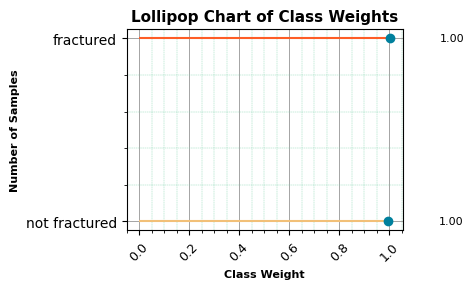

In [16]:
sorted_indices = torch.argsort(class_weights)
sorted_weights = class_weights[sorted_indices]
sorted_names = [list(train_samples.keys())[i] for i in sorted_indices]

plt.figure(figsize=(5, 3), dpi=100)
plt.hlines(y=sorted_names, xmin=0, xmax=sorted_weights.numpy(), color=PALETTES.summer[10:])
plt.plot(sorted_weights.numpy(), sorted_names, 'o', color=PALETTES.kids[3])

for x, y in zip(sorted_weights, sorted_names):
    plt.text(x + 0.2, y, f"{x:.2f}", va='center', fontsize=8)


plt.xlabel("Class Weight", fontsize=8, weight='bold')
plt.xticks(rotation=45, fontsize=9)
plt.ylabel('Number of Samples', fontsize=8, weight='bold')
plt.title("Lollipop Chart of Class Weights", fontsize=11, weight='bold')
plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.tight_layout()
plt.show()

### Channel Means and Standard Deviations

In the next code cell, we will **compute the mean and standard deviation for each color channel** across all images in the dataset. These values are essential for **normalizing the images** during preprocessing, which helps the models train more effectively and converge faster.

In [17]:
train_data = datasets.ImageFolder(
    root='Bone_Fracture_Dataset/train',
    transform= transforms.Compose([
        transforms.Resize((96, 96)),
        transforms.ToTensor()
      ])
    )
means = torch.zeros(3)
stds = torch.zeros(3)

for img, label in train_data:
  means += torch.mean(img, dim = (1,2))
  stds += torch.std(img, dim = (1,2))

means /= len(train_data)
stds /= len(train_data)

print(f'Calculated means: {means}')
print(f'Calculated stds: {stds}')


Calculated means: tensor([0.2329, 0.2329, 0.2329])
Calculated stds: tensor([0.2041, 0.2041, 0.2041])


From the computed channel means and standard deviations, we will **average them to obtain a single value**. This value will be used to **normalize all images**. Additionally, the images will be **resized to 96×96 pixels** and **converted to grayscale**. For the training set, we will also apply **data augmentation** to improve model generalization.  

The transformations for each dataset split are as follows:

```python
"train": transforms.Compose([
    transforms.Resize([96, 96]),
    transforms.RandomRotation(5),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomCrop(96, padding=2),
    transforms.ToTensor(),
    transforms.Grayscale(num_output_channels=1),
    transforms.Normalize(mean=[mean], std=[std], inplace=False)
]),
"valid": transforms.Compose([
    transforms.Resize([96, 96]),
    transforms.ToTensor(),
    transforms.Grayscale(num_output_channels=1),
    transforms.Normalize(mean=[mean], std=[std], inplace=False)
]),
"test": transforms.Compose([
    transforms.Resize([96, 96]),
    transforms.ToTensor(),
    transforms.Grayscale(num_output_channels=1),
    transforms.Normalize(mean=[mean], std=[std], inplace=False)
])
```


These transformations ensure that the data is standardized, and the training set benefits from random augmentations to make the model more robust.

In [18]:
mean = means.mean().item()
std = stds.mean().item()

image_transforms = {
    "train": transforms.Compose([
       transforms.Resize([96,96]),
       transforms.RandomRotation(5),
       transforms.RandomHorizontalFlip(.5),
       transforms.RandomCrop(96, padding=2),
       transforms.ToTensor(),
       transforms.Grayscale(
         num_output_channels =1
       ),
       transforms.Normalize(mean=[mean], std=[std], inplace=False)                         
    ]),
    "valid": transforms.Compose([
        transforms.Resize([96,96]),
        transforms.ToTensor(),
        transforms.Grayscale(
         num_output_channels=1
       ),
        transforms.Normalize(mean=[mean], std=[std], inplace=False)
    ]),
    "test": transforms.Compose([
        transforms.Resize([96,96]),
        transforms.ToTensor(),
        transforms.Grayscale(
         num_output_channels =1
       ),
        transforms.Normalize(mean=[mean], std=[std], inplace=False)
    ])
}

In the following code cell, we will create datasets using the `ImageFolder` class from PyTorch. This class **automatically maps each class to its corresponding images** and handles much of the underlying data management, making it easy to prepare both the **training** and **testing** sets for model training and evaluation.


In [19]:
train_dataset = datasets.ImageFolder('Bone_Fracture_Dataset/train', transform = image_transforms['train'])
test_dataset = datasets.ImageFolder('Bone_Fracture_Dataset/test', transform = image_transforms['test'])
valid_dataset = datasets.ImageFolder('Bone_Fracture_Dataset/val', transform = image_transforms['valid'])
class_names = train_dataset.classes
class_names

['fractured', 'not fractured']

We can check the class to index mapping of the dataset as follows..

In [20]:
train_dataset.class_to_idx

{'fractured': 0, 'not fractured': 1}

In the following code cell we are going to use the pie chat to visualize the examples that we have in each subset.

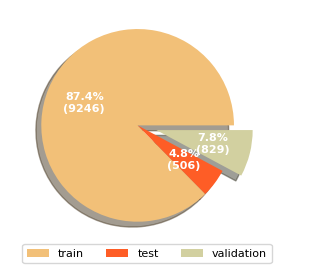

In [21]:
plt.figure(figsize=(3, 3))

plt.pie(
    [len(train_dataset), len(test_dataset), len(valid_dataset)], explode= [.0, .0, .1],
    labels=['train', 'test', 'validation'],
    pctdistance=0.6, shadow=True, autopct=lambda x: fmt(x, sum([len(train_dataset), len(test_dataset), len(valid_dataset)])),
    textprops={'color': 'white', 'fontsize': 8, 'weight': 'bold'},
    radius=.5, colors=PALETTES.summer[10:]
)
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, .01),
    ncol=4,
    fontsize=8
)
plt.axis('equal')
plt.show()

Next we are going to create iterators and we are going to set the batch size to be `128`.

In [22]:
BATCH_SIZE = 128
train_iterator = data.DataLoader(
    train_dataset, shuffle=True, batch_size= BATCH_SIZE
)
valid_iterator = data.DataLoader(
    valid_dataset, batch_size= BATCH_SIZE
)
test_iterator = data.DataLoader(
    test_dataset,  batch_size= BATCH_SIZE
)

### Visualizing Images

In this section of the notebook we are going to visualize the images that we have in our dataset with their respective labels.

In [23]:
def normalize_image(image):
  image_min = image.min()
  image_max = image.max()
  image.clamp_(min = image_min, max = image_max)
  image.add_(-image_min).div_(image_max - image_min + 1e-5)
  return image

Next we are going to define the `plot_images` function which is responsible for plotting images.

In [24]:
def plot_images(images, labels, normalize = True):
  n_images = len(images)
  rows = int(np.sqrt(n_images))
  cols = int(np.sqrt(n_images))
  fig = plt.figure(figsize = (10, 10))
  for i in range(rows*cols):
    ax = fig.add_subplot(rows, cols, i+1)
    image = images[i]
    if normalize:
        image = normalize_image(image)

    ax.imshow(image.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    ax.set_title(class_names[labels[i]], fontsize=10, color='g' if labels[i] == 1 else 'r')
    ax.axis('off')


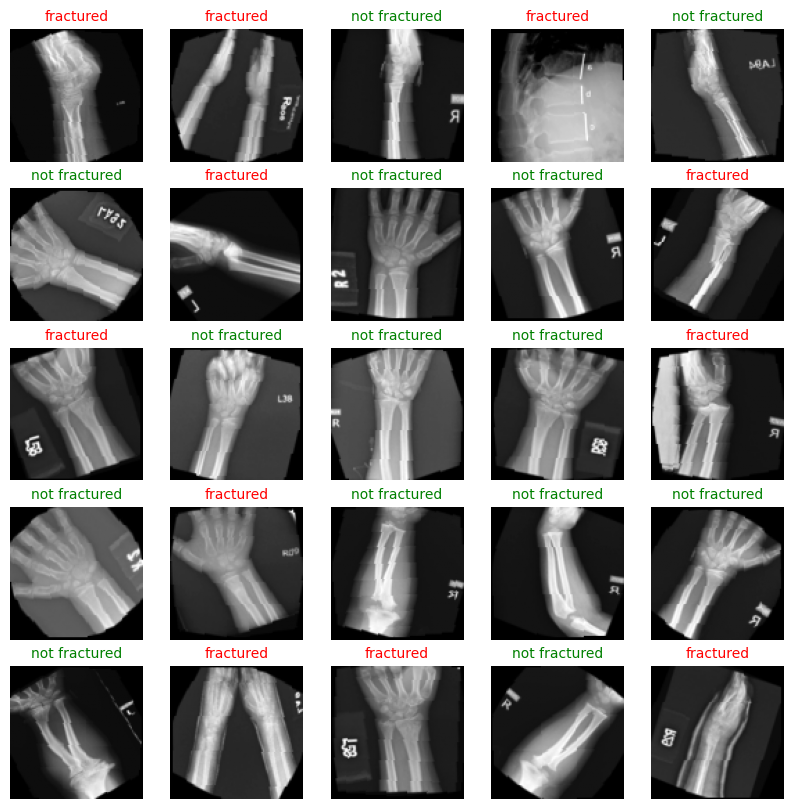

In [25]:
N_IMAGES = 25
labeled_data = next(iter(train_iterator))

images, labels = labeled_data[0][:N_IMAGES], labeled_data[1][:N_IMAGES]
plot_images(images, labels)

### MLP Model

In the next code cell, we will **define a Multilayer Perceptron (MLP) model**. This fully connected neural network will serve as a **lightweight baseline** for bone fracture classification and will process the flattened X-ray image data to predict the corresponding class labels.

The MLP model provides a simple yet effective benchmark for evaluating the performance of more complex architectures.

In [43]:
class MLP(nn.Module):
  def __init__(self, input_dim, output_dim, dropout=.5):
    super(MLP, self).__init__()
    self.classifier = nn.Sequential(
        nn.Linear(input_dim, 250),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(250, 100),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(100, output_dim)
    )

  def forward(self, x):
    batch_size = x.shape[0]
    x = x.view(batch_size, -1)
    x = self.classifier(x)
    return x

### LeNet

In the following code cell, we will **define a LeNet model**. Unlike a standard MLP, LeNet is a **convolutional neural network (CNN)** that extracts spatial features from images, making it well-suited for image classification tasks such as bone fracture detection from X-ray images. 

This model serves as a **lightweight yet effective baseline**, allowing us to compare its performance against the MLP model.

In [44]:
class LeNet(nn.Module):
    def __init__(self, output_dim, input_size=96):
        super(LeNet, self).__init__()
        self.convs = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),                 
            nn.Conv2d(6, 16, kernel_size=5),  
            nn.ReLU(),
            nn.MaxPool2d(2)                 
        )
        
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_size, input_size)
            dummy = self.convs(dummy)
            self.flatten_dim = dummy.view(1, -1).shape[1]
        self.classifier = nn.Sequential(
            nn.Linear(self.flatten_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        x = self.convs(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In the following code cell, we will **create an instance of the `MLP` model**. This step initializes the model with the defined architecture, making it ready for training on the bone fracture X-ray dataset.

In [45]:
OUTPUT_DIM = 1 if len(class_names) == 2 else len(class_names)

INPUT_DIM = 96 * 96
OUTPUT_DIM = 1 if len(class_names) == 2 else len(class_names)
dropout = .5
mlp = MLP(INPUT_DIM, OUTPUT_DIM, dropout).to(device)
mlp

MLP(
  (classifier): Sequential(
    (0): Linear(in_features=9216, out_features=250, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=250, out_features=100, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=100, out_features=1, bias=True)
  )
)

In the following code cell, we will **create an instance of the `LeNet` model**. This initializes the convolutional network with the defined architecture, preparing it for training and evaluation on the bone fracture X-ray dataset.

In [46]:
lenet = LeNet(OUTPUT_DIM).to(device)
lenet

LeNet(
  (convs): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=7056, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

### Model Complexity Analysis

In this section, the computational complexity of the model is analyzed by estimating the number of **parameters** and **floating point operations (FLOPs)**. These metrics quantify the amount of computation required during a forward pass.

FLOPs are commonly approximated as:
- **2 x MACs (Multiply-Accumulate Operations)**  
  - One multiplication  
  - One addition  

The computation of FLOPs varies depending on the layer type:

### Fully Connected Layers
For fully connected (dense) layers, FLOPs are determined by:
- The number of input units  
- The number of output units  

This reflects the total number of connections between neurons.

### Convolutional Layers
For convolutional layers, FLOPs depend on:
- Kernel size (height x width)  
- Number of input channels  
- Number of output channels  
- Spatial dimensions of the output feature map  

These factors collectively determine how many operations are required to produce each feature map.


### Importance of Complexity Analysis

Evaluating model complexity is important for:
- Comparing computational efficiency  
- Estimating inference time  
- Assessing suitability for deployment in **resource-constrained environments**  

This is particularly relevant for lightweight architectures such as **LeNet**, where efficiency is a key advantage.


### Limitations of FLOPs

While FLOPs provide a useful estimate of computational cost, they have limitations:
- Do not account for memory access overhead  
- Ignore hardware-specific optimizations (e.g., GPU parallelism)  
- May not fully reflect real-world runtime performance  

As a result, models with similar FLOPs can still exhibit different practical performance depending on the execution environment.

In [47]:
def count_params(model):
  total_params = sum([p.numel() for p in model.parameters()])
  trainable_params = sum([p.numel() for p in model.parameters() if p.requires_grad])
  return f'{total_params:,}', f'{trainable_params:,}', f'{total_params - trainable_params:,}'

def compute_flops(model):
    with torch.cuda.device(0):
        macs, params = get_model_complexity_info(
            model,
            (1, 96, 96),
            as_strings=True,
            print_per_layer_stat=False,
            verbose=False
        )
    return macs, params

In [48]:
def count_params(model):
  total_params = sum([p.numel() for p in model.parameters()])
  trainable_params = sum([p.numel() for p in model.parameters() if p.requires_grad])
  return f'{total_params:,}', f'{trainable_params:,}', f'{total_params - trainable_params:,}'

Then we will visualize the model parameters using a table.

In [49]:
tabulate_data(
    ["NAME", "TOTAL PARAMETERS", "TRAINABLE PARAMETERS", "NON-TRAINABLE PARAMETERS", "FLOPs (MACs)", "SHORTENED PARAMS",],
    [
      ['lenet', *count_params(lenet), *compute_flops(lenet)],
      ['mlp', *count_params(mlp), *compute_flops(mlp)],
    ],
    "MODELS' COMPLEXITY"
)

MODELS' COMPLEXITY
+-------+------------------+----------------------+--------------------------+--------------+------------------+
| NAME  | TOTAL PARAMETERS | TRAINABLE PARAMETERS | NON-TRAINABLE PARAMETERS | FLOPs (MACs) | SHORTENED PARAMS |
+-------+------------------+----------------------+--------------------------+--------------+------------------+
| lenet |          914,189 |              914,189 |                        0 |    6.81 MMac |         914.19 k |
| mlp   |        2,329,451 |            2,329,451 |                        0 |    2.33 MMac |           2.33 M |
+-------+------------------+----------------------+--------------------------+--------------+------------------+


### Criterion and Optimizer

Next, we define the **optimizer** and **loss function** for training the models. We use the **Adam optimizer** with its default parameters for efficient gradient-based optimization.

For the loss function, we use **BCEWithLogitsLoss()**, which is appropriate for **binary classification tasks** such as bone fracture detection. This loss function combines a sigmoid activation with binary cross-entropy, providing numerical stability during training.

In addition, **class weights** are incorporated into the loss function to address class imbalance. This ensures that:
- Errors on minority classes are penalized more heavily  
- The model does not become biased toward majority classes  
- Learning remains balanced across all classes  


In [59]:
optimizers = {
    'mlp': torch.optim.Adam(mlp.parameters()),
    'lenet': torch.optim.Adam(lenet.parameters()),
}
pos_weight = torch.tensor([class_weights.max() /class_weights.min()]).to(device)

criterions = {
    'mlp': nn.BCEWithLogitsLoss(pos_weight=pos_weight).to(device),
    'lenet': nn.BCEWithLogitsLoss(pos_weight=pos_weight).to(device),
}
criterions = {
    'mlp': nn.BCEWithLogitsLoss(pos_weight=pos_weight).to(device),
    'lenet': nn.BCEWithLogitsLoss(pos_weight=pos_weight).to(device),
}

In the following code cell, we define the `binary_accuracy` function. This function **computes the classification accuracy** by comparing the model’s predicted labels with the ground truth labels. 

For binary classification, predictions are typically obtained by applying a sigmoid activation followed by thresholding (e.g., at 0.5) to determine the predicted class. The resulting accuracy provides a clear and interpretable metric for evaluating model performance on the bone fracture detection task.

In [60]:
def binary_accuracy(y_preds, y_true):
  rounded_preds = torch.round(torch.sigmoid(y_preds))
  correct = (rounded_preds == y_true).float()
  return correct.sum() / len(correct)

### Train and Evaluate Functions

In the following code cell we are going to define the `train` and `evaluate` fuctions.

In [61]:
def train(model, iterator, optimizer, criterion, device):
  epoch_loss, epoch_acc = 0, 0
  model.train()
  for (x, y) in iterator:
    # features and labels to the device
    x = x.to(device)
    y = y.to(device).float()
    # Zero the gradients
    optimizer.zero_grad()
    y_pred = model(x)
    # Calculate the loss and accuracy
    y_pred = y_pred.squeeze()

    loss = criterion(y_pred, y)
    acc = binary_accuracy(y_pred, y)
    # Backward propagate
    loss.backward()
    # Update the weights
    optimizer.step()
    epoch_loss +=loss.item()
    epoch_acc += acc.item()
  return epoch_loss/len(iterator), epoch_acc/len(iterator)

def evaluate(model, iterator, criterion, device):
  epoch_loss, epoch_acc = 0, 0
  model.eval()
  with torch.no_grad():
    for (x, y) in iterator:
      x = x.to(device)
      y = y.to(device).float()
      y_pred = model(x)
      y_pred = y_pred.squeeze()
      loss = criterion(y_pred, y)
      acc = binary_accuracy(y_pred, y)

      epoch_loss += loss.item()
      epoch_acc += acc.item()
  return epoch_loss/len(iterator), epoch_acc/len(iterator)

Next we are going to create a `History` wrapper class so that we can keep in track of the model's metrics during training.

In [62]:
class History:
  def __init__(self):
    self.train_losses = list()
    self.train_acc = list()
    self.epoch_train_time = list()
    self.val_losses = list()
    self.val_acc = list()

  def add(self, train_loss:float, train_acc:float, val_loss:float, val_acc:float, elt:float):
    self.train_losses.append(train_loss)
    self.val_losses.append(val_loss)
    self.train_acc.append(train_acc)
    self.val_acc.append(val_acc)
    self.epoch_train_time.append(elt)

Next we are going to define the `train_model` function which is responsible for training the model and return model training history.

In [63]:
EPOCHS = 100

def train_model(model, model_name, train_iterator, optimizer, criterion, device, valid_iterator):
  best_valid_loss = float('inf')
  column_names = ["Set", "Loss", "Accuracy", "ETA (time)"]
  last_saved_epoch = 1

  history = History()
  training_start = time.time()
  for epoch in range(EPOCHS):
    start = time.time()

    train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device)

    save_status = "(not saving)"
    if valid_loss < best_valid_loss:
      best_valid_loss = valid_loss
      save_status = "(saving)"
      last_saved_epoch = epoch + 1
      torch.save(model.state_dict(), model_name)

    end = time.time()
    history.add(train_loss, train_acc, valid_loss, valid_acc, end-start)

    data_rows = [
        ["Train", f'{train_loss:.3f}', f'{train_acc * 100:.2f}%', hms_string(end-start)],
        ["Validation", f'{valid_loss:.3f}', f'{valid_acc * 100:.2f}%', ""]
    ]
    title = f"{model_name.replace('.pt', '')}: EPOCH {epoch+1:02}/{EPOCHS}: {save_status}"
    print(title)
    for row in data_rows:
        print(" | ".join(row), ' |')
    print()
    

  training_end = time.time()
  return history, training_end - training_start, last_saved_epoch

Next we are going to run the train loop for the `MLP` model.

In [64]:
mlp_history, mlp_training_end, mlp_last_saved_epoch = train_model(
    mlp, 'mlp.pt', train_iterator, optimizers['mlp'], criterions['mlp'], device, valid_iterator
)

mlp: EPOCH 01/100: (saving)
Train | 0.667 | 63.94% | 0:01:13.82  |
Validation | 0.692 | 67.41% |   |

mlp: EPOCH 02/100: (saving)
Train | 0.545 | 72.58% | 0:01:14.18  |
Validation | 0.584 | 76.54% |   |

mlp: EPOCH 03/100: (saving)
Train | 0.469 | 78.29% | 0:01:12.72  |
Validation | 0.529 | 79.56% |   |

mlp: EPOCH 04/100: (saving)
Train | 0.415 | 82.01% | 0:01:12.62  |
Validation | 0.425 | 84.77% |   |

mlp: EPOCH 05/100: (not saving)
Train | 0.377 | 84.10% | 0:01:11.17  |
Validation | 0.464 | 83.12% |   |

mlp: EPOCH 06/100: (saving)
Train | 0.354 | 85.21% | 0:01:11.87  |
Validation | 0.397 | 84.72% |   |

mlp: EPOCH 07/100: (saving)
Train | 0.324 | 86.67% | 0:01:10.13  |
Validation | 0.335 | 86.48% |   |

mlp: EPOCH 08/100: (not saving)
Train | 0.308 | 87.61% | 0:01:14.17  |
Validation | 0.395 | 87.97% |   |

mlp: EPOCH 09/100: (saving)
Train | 0.281 | 88.73% | 0:01:10.70  |
Validation | 0.273 | 89.16% |   |

mlp: EPOCH 10/100: (saving)
Train | 0.248 | 90.07% | 0:01:11.47  |
Validat

Next we are going to run the train loop for the `LeNet` model.

In [65]:
lenet_history, lenet_training_end, lenet_last_saved_epoch = train_model(
    lenet, 'lenet.pt', train_iterator, optimizers['lenet'], criterions['mlp'], device, valid_iterator
)

lenet: EPOCH 01/100: (saving)
Train | 0.549 | 70.99% | 0:01:05.03  |
Validation | 0.438 | 81.14% |   |

lenet: EPOCH 02/100: (saving)
Train | 0.328 | 86.57% | 0:01:03.80  |
Validation | 0.382 | 85.09% |   |

lenet: EPOCH 03/100: (saving)
Train | 0.193 | 93.07% | 0:01:05.48  |
Validation | 0.316 | 89.46% |   |

lenet: EPOCH 04/100: (saving)
Train | 0.119 | 96.04% | 0:01:03.75  |
Validation | 0.294 | 89.92% |   |

lenet: EPOCH 05/100: (saving)
Train | 0.073 | 97.57% | 0:01:03.63  |
Validation | 0.266 | 91.25% |   |

lenet: EPOCH 06/100: (saving)
Train | 0.055 | 98.41% | 0:01:03.86  |
Validation | 0.196 | 94.24% |   |

lenet: EPOCH 07/100: (not saving)
Train | 0.049 | 98.35% | 0:01:07.33  |
Validation | 0.203 | 92.28% |   |

lenet: EPOCH 08/100: (saving)
Train | 0.029 | 99.10% | 0:01:12.80  |
Validation | 0.132 | 96.33% |   |

lenet: EPOCH 09/100: (not saving)
Train | 0.036 | 98.84% | 0:01:04.63  |
Validation | 0.154 | 94.81% |   |

lenet: EPOCH 10/100: (not saving)
Train | 0.028 | 98.98%

### Model Training Time

In the following code cell, we will use a **table** to display the **total training time** for the model as well as the **last saved epoch**. This provides a quick summary of training efficiency and progress for each model.


In [66]:
rows = [
    ['lenet', f'{EPOCHS}', f'{hms_string(lenet_training_end)}', f'{lenet_last_saved_epoch}', *compute_flops(lenet)],
    ['mlp', f'{EPOCHS}', f'{hms_string(mlp_training_end)}', f'{mlp_last_saved_epoch}', *compute_flops(mlp)],
]
tabulate_data(['MODEL','TOTAL EPOCHS', 'TOTAL TRAINING TIME',
               'LAST SAVED EPOCH', "FLOPs (MACs)", "PARAMS"], rows, "TOTAL TRAINING TIME")

TOTAL TRAINING TIME
+-------+--------------+---------------------+------------------+--------------+----------+
| MODEL | TOTAL EPOCHS | TOTAL TRAINING TIME | LAST SAVED EPOCH | FLOPs (MACs) |   PARAMS |
+-------+--------------+---------------------+------------------+--------------+----------+
| lenet |          100 |          1:48:09.56 |              100 |    6.81 MMac | 914.19 k |
| mlp   |          100 |          1:51:50.02 |               91 |    2.33 MMac |   2.33 M |
+-------+--------------+---------------------+------------------+--------------+----------+


In the following code cell, we will **visualize the model's training time per epoch**. This allows us to analyze how long each epoch takes and helps identify any potential bottlenecks in the training process.


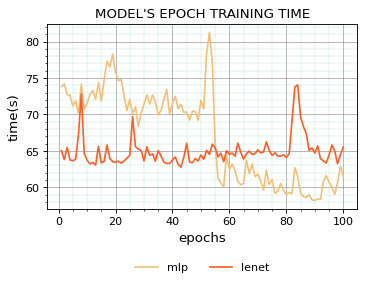

In [67]:
epochs = np.arange(1, EPOCHS + 1)
plt.figure(figsize=(5, 3), dpi=80)
plt.plot(epochs, mlp_history.epoch_train_time, label="mlp", color=PALETTES.summer[10])
plt.plot(epochs, lenet_history.epoch_train_time, label="lenet", color=PALETTES.summer[11])
plt.title("MODEL'S EPOCH TRAINING TIME", color="k", fontsize=12)
plt.xlabel("epochs", fontsize=12)
plt.ylabel("time(s)", fontsize=12)

plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.legend(loc="lower center",
    ncol=3, frameon=False, fontsize=10, title="",
    bbox_to_anchor=(0.5, -.4),
)
plt.show()

### Validation and Training Accuracies

In the following code cell, we will **visualize the model's training and validation accuracies per epoch** using line graphs. This provides insight into how well the model is learning over time and helps monitor **performance improvements** across epochs.


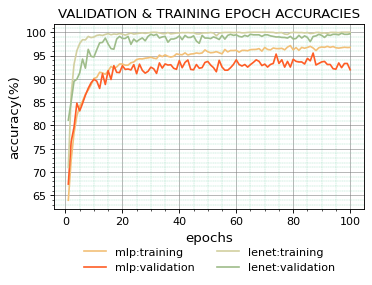

In [68]:
plt.figure(figsize=(5, 3), dpi=80)
plt.plot(epochs, [i * 100 for i in mlp_history.train_acc], label="mlp:training", color=PALETTES.summer[10])
plt.plot(epochs, [i * 100 for i in mlp_history.val_acc], label="mlp:validation", color=PALETTES.summer[11])
plt.plot(epochs, [i * 100 for i in lenet_history.train_acc], label="lenet:training", color=PALETTES.summer[12])
plt.plot(epochs, [i * 100 for i in lenet_history.val_acc], label="lenet:validation", color=PALETTES.summer[13])

plt.title("VALIDATION & TRAINING EPOCH ACCURACIES", color="k", fontsize=12)
plt.xlabel("epochs", fontsize=12)
plt.ylabel("accuracy(%)", fontsize=12)
plt.legend(loc="lower center",
    ncol=2, frameon=False, fontsize=10, title="",
    bbox_to_anchor=(0.5, -.4),
)
plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.show()

### Validation and Training Losses

In the following code cell, we will **visualize the model's training and validation losses per epoch** using line graphs. This helps track the model's learning progress and identify potential issues like **overfitting** or **underfitting**.


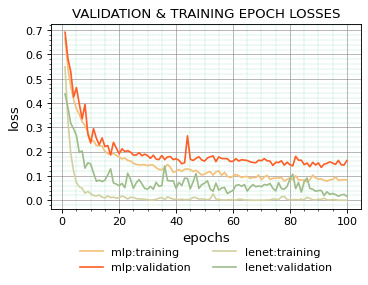

In [115]:
plt.figure(figsize=(5, 3), dpi=80)

plt.plot(epochs, mlp_history.train_losses, label="mlp:training", color=PALETTES.summer[10])
plt.plot(epochs, mlp_history.val_losses, label="mlp:validation", color=PALETTES.summer[11])
plt.plot(epochs, lenet_history.train_losses, label="lenet:training", color=PALETTES.summer[12])
plt.plot(epochs, lenet_history.val_losses, label="lenet:validation", color=PALETTES.summer[13])

plt.title("VALIDATION & TRAINING EPOCH LOSSES", color="k", fontsize=12)
plt.xlabel("epochs", fontsize=12)
plt.ylabel("loss", fontsize=12)
plt.legend(loc="lower center",
    ncol=2, frameon=False, fontsize=10, title="",
    bbox_to_anchor=(0.5, -.4),
)
plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.show()

### Best Model Evaluation

In the following code cell, we will **define a function to evaluate the best saved model** from training. This function will compute both the **loss** and **accuracy** on the **testing dataset**, providing a clear measure of how well the model generalizes to unseen data.


In [90]:
def evaluate_best_model(model, model_name, test_iterator, criterion, device):
  model.load_state_dict(torch.load(model_name, weights_only=True))
  test_loss, test_acc = evaluate(model, test_iterator, criterion, device)
  return f'{test_loss:.2f}', f'{test_acc * 100:.2f}'

tabulate_data(
    ["NAME", "LOSS", "ACCURACY (%)"],
    [
        ['mlp', *evaluate_best_model(mlp, 'mlp.pt', test_iterator, criterions['mlp'], device)],
        ['lenet', *evaluate_best_model(lenet, 'lenet.pt', test_iterator, criterions['lenet'], device)],
    ],
    "BEST MODEL'S LOSS AND ACCURACY"
)

BEST MODEL'S LOSS AND ACCURACY
+-------+------+--------------+
| NAME  | LOSS | ACCURACY (%) |
+-------+------+--------------+
| mlp   | 0.11 |        95.29 |
| lenet | 0.04 |        99.22 |
+-------+------+--------------+


### Model Evaluation Metrics

In this section, we will **evaluate the best-performing model** and visualize its performance using key metrics. For this multi-class classification task, we will use:

1. **Confusion Matrix** – to see how well the model predicts each class.  
2. **Classification Report** – to get precision, recall, F1-score, and support for each class.  

The first step is to **obtain predictions** from the training dataset, which will then be used to compute these evaluation metrics.


In [91]:
def get_predictions(model, iterator, device):
  model.eval()
  images = []
  labels = []
  probs = []
  with torch.no_grad():
    for (x, y) in iterator:
      x = x.to(device)
      y_pred = model(x)
      y_prob = F.sigmoid(y_pred).squeeze().detach()
      images.append(x.cpu())
      labels.append(y.cpu())
      probs.append(y_prob)
  images = torch.cat(images, dim = 0)
  labels = torch.cat(labels, dim = 0)
  probs = torch.cat(probs, dim = 0)
  return images, labels, probs

mlp_test_images, mlp_test_labels, mlp_probs = get_predictions(mlp, test_iterator, device)
lenet_test_images, lenet_test_labels, lenet_probs = get_predictions(lenet, test_iterator, device)

Next we are going to convert our predictions from probabilities to real labels.

In [92]:
mlp_preds = torch.round(mlp_probs).cpu().numpy().astype(np.int32)
mlp_test_labels = mlp_test_labels.numpy()

lenet_preds = torch.round(lenet_probs).cpu().numpy().astype(np.int32)
lenet_test_labels = lenet_test_labels.numpy()

### Plotting Predictions

In this section, we will **visualize the model's predictions** on sample images from the dataset. This helps to **qualitatively assess** how well the model is performing and provides an intuitive understanding of its classification behavior.


In [93]:
def get_predictions_labels(test_images, preds, test_labels):
    test_images_labels = list(zip(test_images, preds, test_labels))
    random.shuffle(test_images_labels)
    y_true = []
    y_pred = []
    images = []
    for img, pred, label in test_images_labels[:24]:
      y_true.append(label)
      y_pred.append(pred)
      images.append(img)
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return images, y_true, y_pred

mlp_images, mlp_y_true, mlp_y_pred = get_predictions_labels(mlp_test_images, mlp_preds, mlp_test_labels)
lenet_images, lenet_y_true, lenet_y_pred = get_predictions_labels(lenet_test_images, lenet_preds, lenet_test_labels)

Next we are going to define the function that will plot the predictions for us.

In [94]:
def plot_predictions_images(images_and_classes,
                            labels_true, labels_pred,
                            cols=5):
    rows = 3
    fig = plt.figure()
    fig.set_size_inches(cols * 2, rows * 2)
    for i, (image, label_true, label_pred) in enumerate(zip(images_and_classes, labels_true.astype("int32"), labels_pred)):
        plt.subplot(rows, cols, i + 1)
        plt.axis('off')
        image = normalize_image(image)
        plt.imshow(image.permute(1, 2, 0).cpu().numpy(), cmap="gray")
        plt.title(class_names[label_pred], color ='g' if label_true == label_pred else 'r', fontsize=10 )

Next, we will **plot the predictions made by the `MLP` model**. This visualization allows us to **see how accurately the MLP classifies sample images** and to compare its performance against other models like LeNet.


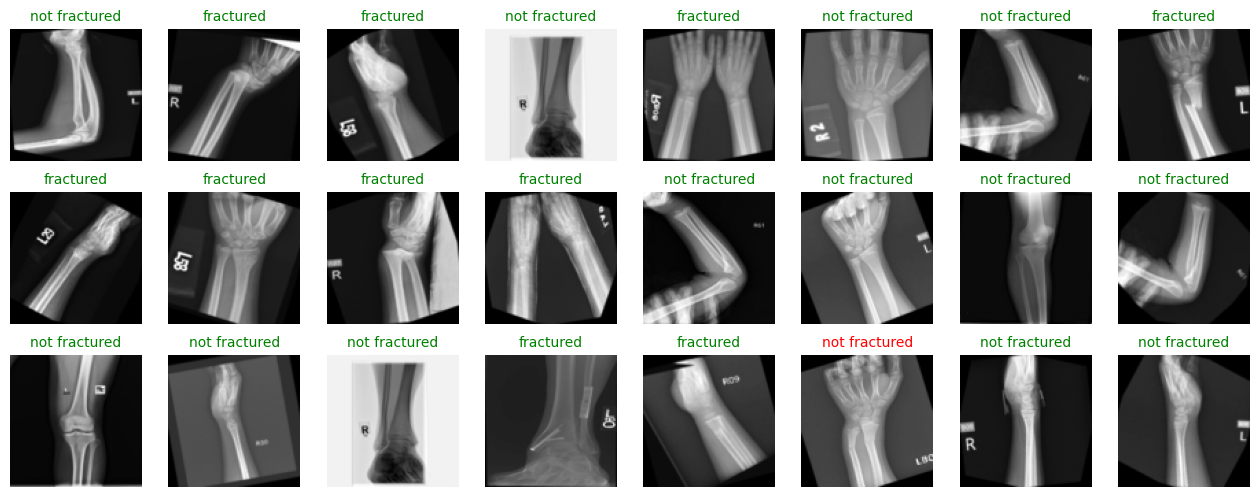

In [95]:
plot_predictions_images(mlp_images[:24], mlp_y_true[:24], mlp_y_pred[:24], cols=8)

Next, we will **plot the predictions made by the `LeNet` model**. This visualization allows us to **see how accurately the LeNeT classifies sample images** and to compare its performance against other models like MLP.


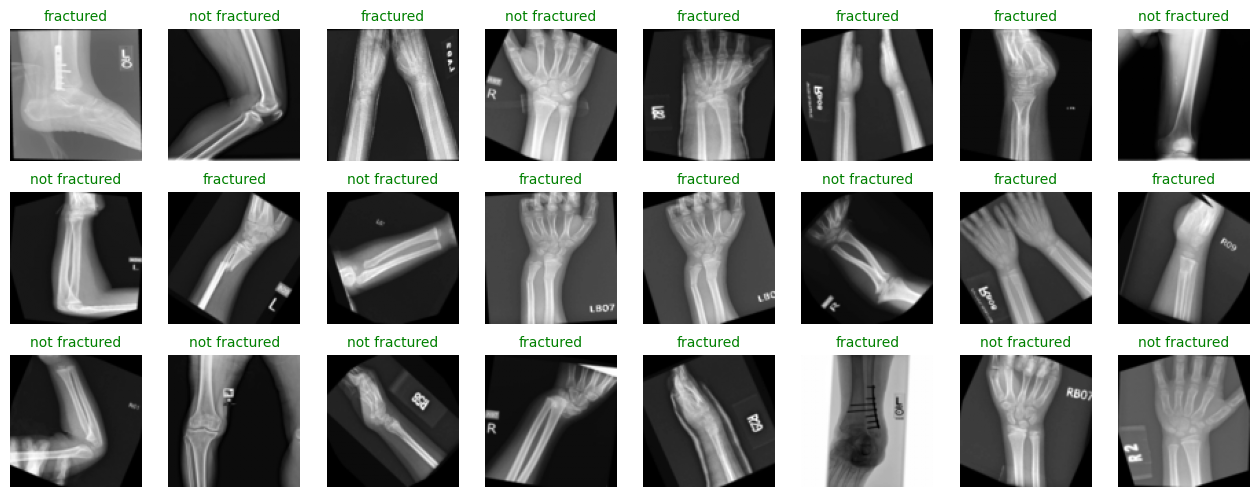

In [96]:
plot_predictions_images(lenet_images[:24], lenet_y_true[:24], lenet_y_pred[:24], cols=8)

### Confusion Matrix

In the following code cell, we will **visualize the confusion matrix** for our model using the **test dataset**. The confusion matrix provides a detailed view of how well the model predicts each class and highlights any misclassifications.

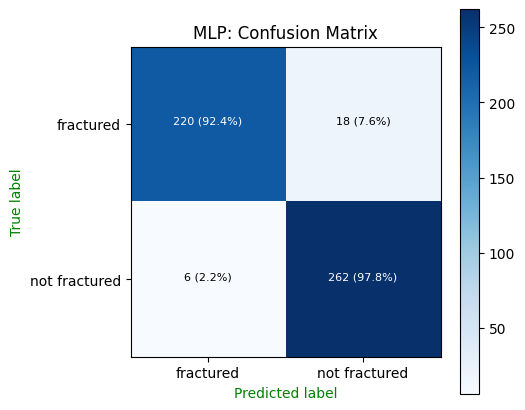

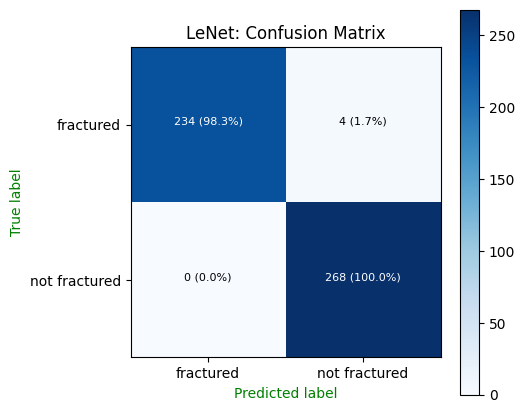

In [97]:
plot_complicated_confusion_matrix(mlp_test_labels, mlp_preds, class_names,
                                  fontsize=8, figsize=(5, 5), title="MLP: Confusion Matrix")
plot_complicated_confusion_matrix(lenet_test_labels, lenet_preds, class_names,
                                  fontsize=8, figsize=(5, 5), title="LeNet: Confusion Matrix")

### Classification Report

In the following code cell, we will **print the classification report** for our best model using the **test dataset**. This report includes **precision, recall, F1-score, and support** for each class, giving a comprehensive overview of the model's performance.


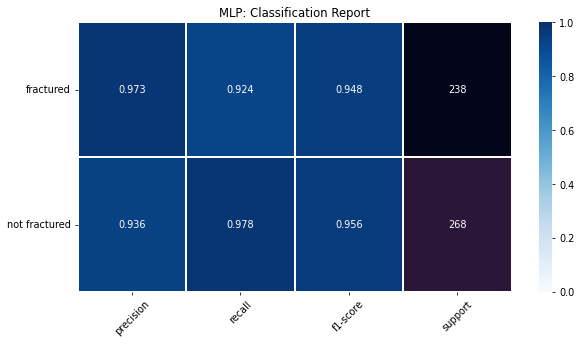

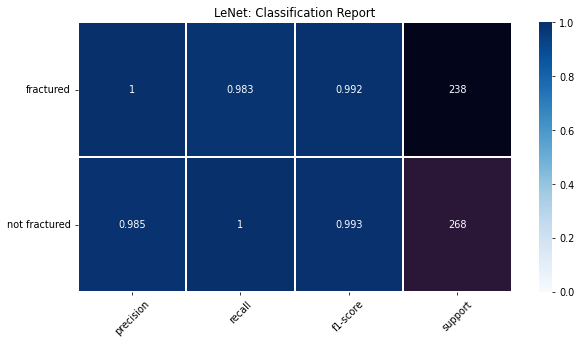

In [98]:
fig, ax = visualization.plot_classification_report(mlp_test_labels, mlp_preds,
                    title='MLP: Classification Report',
                    figsize=(10, 5), dpi=70,
                    target_names = class_names
)

fig, ax = visualization.plot_classification_report(lenet_test_labels, lenet_preds,
                    title='LeNet: Classification Report',
                    figsize=(10, 5), dpi=70,
                    target_names = class_names
)

### Misclassified Bone Fracture Images

In this section, we will **visualize misclassified X-ray images**, if any exist. This helps us **analyze the model's errors** and gain insight into which types of bone structures or fracture patterns are more challenging for the model to classify correctly.

By examining these cases, we can better understand potential limitations of the model and identify areas for improvement.

In [99]:
mlp_corrects = torch.eq(torch.from_numpy(mlp_test_labels), torch.from_numpy(mlp_preds))
lenet_corrects = torch.eq(torch.from_numpy(lenet_test_labels), torch.from_numpy(lenet_preds))

In [100]:
def get_incorrect_examples(images, labels, probabilities, corrects):
  incorrect_examples = []
  for image, label, prob, correct in zip(images, labels, probabilities, corrects):
    if not correct:
      incorrect_examples.append((image, label, prob))
  return incorrect_examples

mlp_incorrect_examples = get_incorrect_examples(mlp_test_images, mlp_test_labels, mlp_probs, mlp_corrects)
lenet_incorrect_examples = get_incorrect_examples(lenet_test_images, lenet_test_labels, lenet_probs, lenet_corrects)

In [101]:
def plot_most_incorrect(incorrect, classes, n_images, normalize = True):
  rows = int(np.sqrt(n_images))
  cols = int(np.sqrt(n_images))
  fig = plt.figure(figsize = (6, 4))
  for i in range(rows*cols):
    ax = fig.add_subplot(rows, cols, i+1)
    image, true_label, probs = incorrect[i]
    image = image.permute(1, 2, 0)
    true_class = classes[true_label]
    incorrect_class = classes[0 if true_label == 1 else 1]
    if normalize:
      image = normalize_image(image)
    ax.imshow(image.cpu().numpy(), cmap="gray")
    ax.set_title(f'real: {true_class}\n' \
                  f'predicted: {incorrect_class}', fontsize=8)
    ax.axis('off')
  fig.subplots_adjust(hspace=0.4)

In the following code cell, we will plot the most mispredicted **bone fracture X-ray images** by the model. This allows us to identify and examine the instances where the model is least confident or makes incorrect predictions.

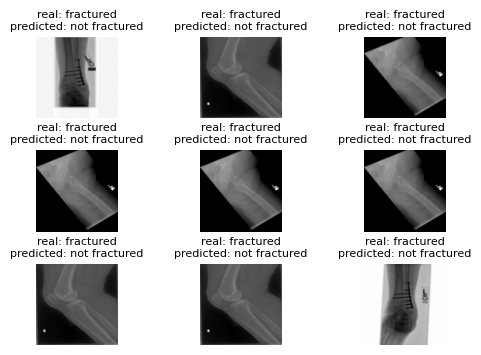

In [102]:
N_IMAGES = 12
try:
    plot_most_incorrect(mlp_incorrect_examples, class_names, N_IMAGES)
except:
    print("No incorrectly Predicted Images")

No incorrectly Predicted Images


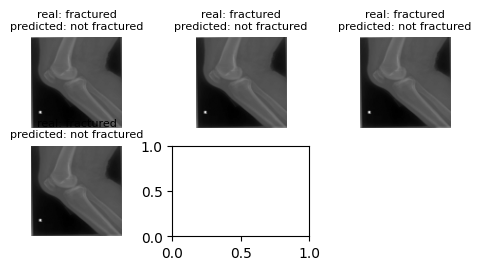

In [103]:
N_IMAGES = 12
try:
    plot_most_incorrect(lenet_incorrect_examples, class_names, N_IMAGES)
except:
    print("No incorrectly Predicted Images")

### Grad-CAM for Qualitative Misclassification Analysis

**Gradient-weighted Class Activation Mapping (Grad-CAM)** is an explainability technique used to visualize which regions of an input image most influenced a convolutional neural network’s prediction. It works by computing gradients of the target class with respect to feature maps to produce a localization heatmap.

In this notebook, Grad-CAM is applied **without retraining the model** as a qualitative tool to interpret model behavior, particularly for **misclassified potato leaf images**. This allows us to assess whether the model focuses on meaningful disease-related regions or irrelevant background patterns.

Grad-CAM is suitable for the **LeNet** model because it contains convolutional layers that preserve spatial information required for localization. In contrast, it is not applicable to models without convolutional feature maps.

For this analysis:
- Heatmaps are generated from the **last convolutional layer**, where higher-level, discriminative features are captured  
- The heatmaps are **overlaid on the original images** to visualize model attention  
- Misclassified samples are specifically analyzed to understand failure cases  

This approach enhances evaluation by complementing quantitative metrics with interpretability, providing deeper insight into model reliability and the underlying causes of misclassification.


In [104]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        
        self.fwd_hook = target_layer.register_forward_hook(self.save_activations)
        self.bwd_hook = target_layer.register_full_backward_hook(self.save_gradients)

    def save_activations(self, module, inp, out):
        self.activations = out.detach()

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, x, class_idx=None):
        self.model.eval()
        self.model.zero_grad()

        output = self.model(x)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        score = output[:, class_idx]
        score.backward()

        grads = self.gradients[0]         # [C, H, W]
        acts = self.activations[0]        # [C, H, W]

        weights = grads.mean(dim=(1, 2))  # [C]
        cam = torch.zeros(acts.shape[1:], device=acts.device)

        for i, w in enumerate(weights):
            cam += w * acts[i]

        cam = F.relu(cam)
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam.cpu().numpy(), class_idx

    def remove_hooks(self):
        self.fwd_hook.remove()
        self.bwd_hook.remove()

In the following code cell, we create a `Grad-CAM` object for the LeNet model to enable visualization of the regions influencing its predictions.

In [105]:
gradcam = GradCAM(lenet, lenet.convs[3])
samples = lenet_incorrect_examples[:N_IMAGES]

### Grad-CAM Visualization of Correctly Classified Samples

In this section, Grad-CAM is applied to **incorrectly classified** bones images from the test set to provide qualitative insight into the **LeNet model's decision-making process**.

For each image, three visualizations are presented:
- The **original image** with its true label  
- The **Grad-CAM heatmap** highlighting the most influential regions for the prediction  
- An **overlay** combining the original image and the heatmap to show where the model focused  

By examining these attention patterns, Grad-CAM provides interpretability that complements quantitative metrics, offering deeper insight into model reliability and confirming that predictions are based on relevant visual cues.

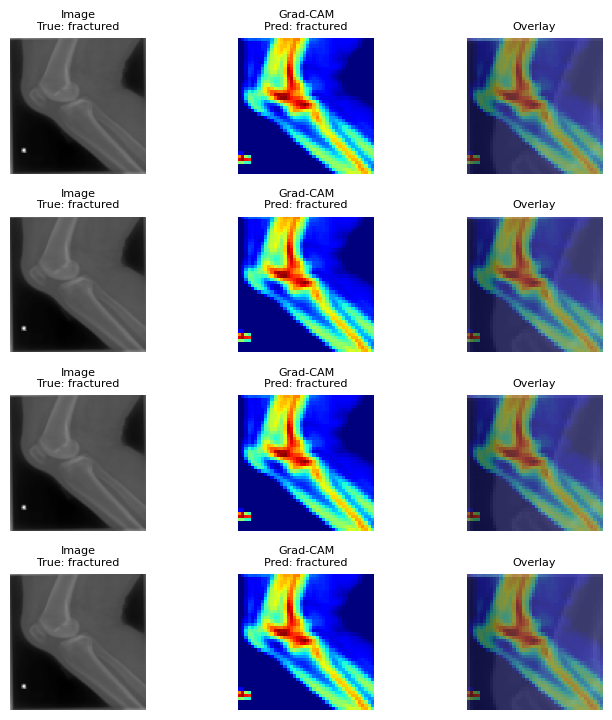

In [106]:
plt.figure(figsize=(7, 1.8 * N_IMAGES))
for i, (image, true_label, prob) in enumerate(samples):
    x = image.unsqueeze(0).to(device)
    cam, pred_class = gradcam.generate(x)
    img = image.squeeze().cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.subplot(N_IMAGES, 3, i * 3 + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Image\nTrue: {class_names[true_label]}", fontsize=8, color='k')
    plt.axis('off')
    
    plt.subplot(N_IMAGES, 3, i * 3 + 2)
    plt.imshow(cam, cmap='jet')
    plt.title(f"Grad-CAM\nPred: {class_names[pred_class]}", fontsize=8, color='k')
    plt.axis('off')
    
    plt.subplot(N_IMAGES, 3, i * 3 + 3)
    plt.imshow(img, cmap='gray')
    plt.imshow(cam, cmap='jet', alpha=0.4)
    plt.title("Overlay", color='k', fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

### Wilson Score Confidence Interval for Model Accuracy

The Wilson Score Interval is a statistical method used to estimate the confidence interval of a population proportion. In classification problems, model accuracy can be treated as a proportion of correctly classified samples.

The Wilson Score Interval is given by:

$$
\frac{\hat{p}+\frac{z^2}{2n}\pm z\sqrt{\frac{\hat{p}(1-\hat{p})}{n}+\frac{z^2}{4n^2}}}{1+\frac{z^2}{n}}
$$

Where:

- $\hat{p}$ : Observed model accuracy
- $n$ : Total number of test samples
- $z$ : Critical value from the standard normal distribution
  - For a 95% confidence interval, $z = 1.96$
- $\pm$ : Represents the lower and upper confidence bounds

The interval estimates the range within which the true model accuracy is expected to lie with a specified level of confidence.

In [107]:
def wilson_score_interval(accuracy, n, confidence=0.95):
    """
    Compute Wilson Score Confidence Interval.

    Parameters:
    accuracy (float): Model accuracy between 0 and 1
    n (int): Number of test samples
    confidence (float): Confidence level (default = 0.95)

    Returns:
    tuple: (lower_bound, upper_bound)
    """
    z_values = {
        0.90: 1.645,
        0.95: 1.96,
        0.99: 2.576
    }
    z = z_values.get(confidence, 1.96)
    denominator = 1 + (z**2 / n)
    centre = accuracy + (z**2 / (2 * n))
    margin = z * math.sqrt(
        (accuracy * (1 - accuracy) / n) +
        (z**2 / (4 * n**2))
    )
    lower = (centre - margin) / denominator
    upper = (centre + margin) / denominator
    return lower, upper

In the following code cell, we compute the `90%`, `95%`, and `99%` confidence intervals for the testing accuracies of the LeNet and MLP models using the Wilson Score Interval method.

In [114]:
mlp_acc = evaluate_best_model(
    mlp, 'mlp.pt', test_iterator, criterions['mlp'], device
)[1]

lenet_acc = evaluate_best_model(
    lenet, 'lenet.pt', test_iterator, criterions['lenet'], device
)[1]

mlp_acc = float(mlp_acc)/100.
lenet_acc = float(lenet_acc)/100.

confidence_levels = [0.90, 0.95, 0.99]
for confidence in confidence_levels:
    mlp_lower, mlp_upper = wilson_score_interval(
        mlp_acc,
        len(test_iterator.dataset),
        confidence=confidence
    )
    lenet_lower, lenet_upper = wilson_score_interval(
        lenet_acc,
        len(test_iterator.dataset),
        confidence=confidence
    )
    tabulate_data(
        ["NAME", "Accuracy (%)", "Lower CI (%)", "Upper CI (%)"],
        [
            ['MLP', mlp_acc * 100, f"{mlp_lower * 100:.2f}", f"{mlp_upper * 100:.2f}"],
            ['LeNet', lenet_acc * 100, f"{lenet_lower * 100:.2f}", f"{lenet_upper * 100:.2f}"],
        ],
        f"{int(confidence * 100)}% CONFIDENCE INTERVAL"
    )
    print("\n")

90% CONFIDENCE INTERVAL
+-------+--------------+--------------+--------------+
| NAME  | Accuracy (%) | Lower CI (%) | Upper CI (%) |
+-------+--------------+--------------+--------------+
| MLP   |        95.29 |        93.49 |        96.61 |
| LeNet |        99.22 |        98.27 |        99.65 |
+-------+--------------+--------------+--------------+


95% CONFIDENCE INTERVAL
+-------+--------------+--------------+--------------+
| NAME  | Accuracy (%) | Lower CI (%) | Upper CI (%) |
+-------+--------------+--------------+--------------+
| MLP   |        95.29 |        93.08 |        96.82 |
| LeNet |        99.22 |        98.00 |        99.70 |
+-------+--------------+--------------+--------------+


99% CONFIDENCE INTERVAL
+-------+--------------+--------------+--------------+
| NAME  | Accuracy (%) | Lower CI (%) | Upper CI (%) |
+-------+--------------+--------------+--------------+
| MLP   |        95.29 |        92.22 |        97.18 |
| LeNet |        99.22 |        97.40 |     